In [13]:
# ========================================
# STATIC FUNCTIONAL CONNECTIVITY EXERCISE
# ========================================

# Install needed packages (if not already)
!pip install nilearn

# ===================== LIBRARIES =====================
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.stats import zscore

# ===================== PATHS =====================
path_exercise = '/content/drive/MyDrive/ColabNotebooks2026/EE-629/EX_1/'
tcs_file = os.path.join(path_exercise, 'DATA', 'TCS.mat')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ===================== LOAD TIMECOURSES =====================
tcs = scipy.io.loadmat(tcs_file)
print("Variables in .mat file:", tcs.keys())

# Extract the main timecourse variable
TCSvar = tcs['X']  # shape: (regions, timepoints, subjects)
print("TCS shape (regions x timepoints x subjects):", TCSvar.shape)

n_regions, n_timepoints, n_subjects = TCSvar.shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'X'])
TCS shape (regions x timepoints x subjects): (379, 1200, 100)


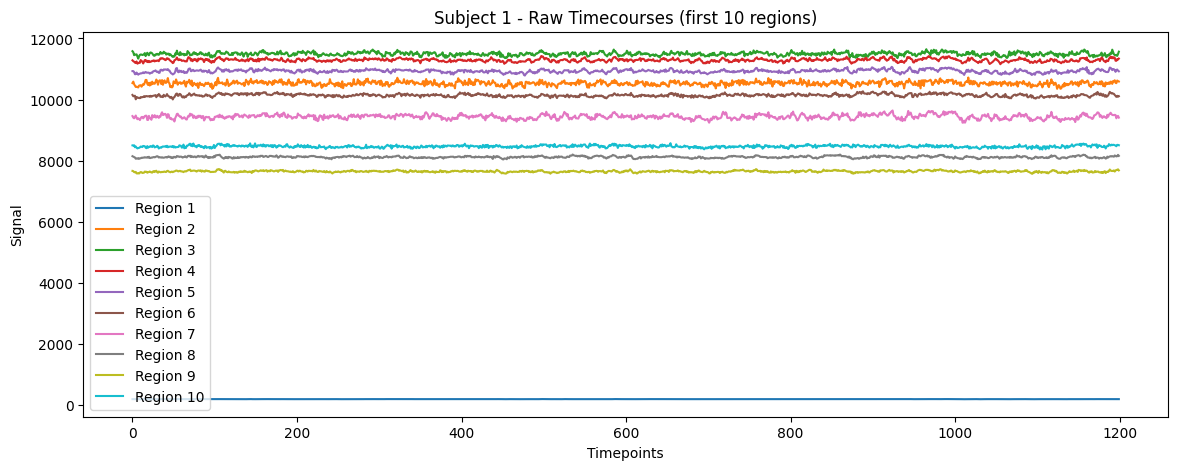

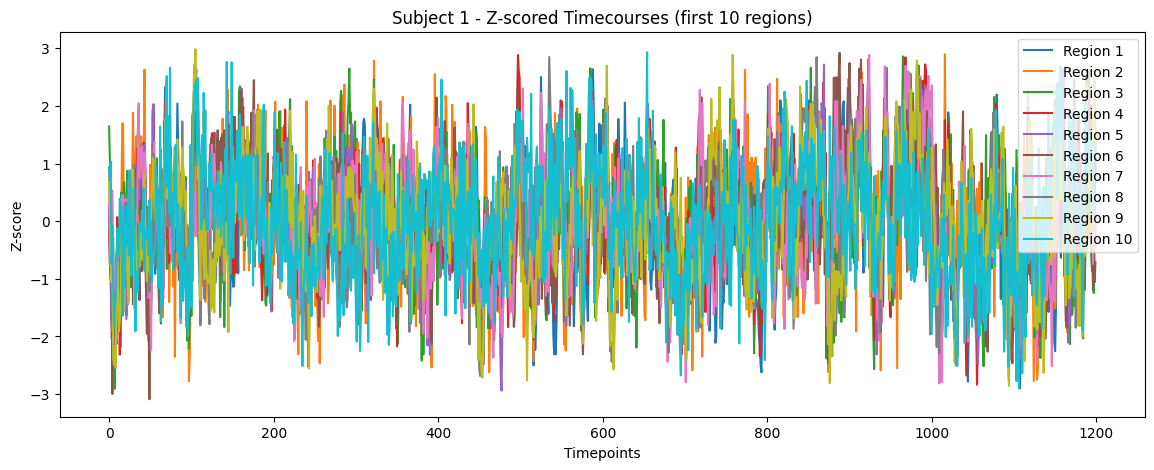

In [14]:

# ===================== PLOT TIMECOURSES =====================
subject_idx = 0  # first subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Plot first 10 regions - raw vs z-scored
plt.figure(figsize=(14,5))
for r in range(10):
    plt.plot(tc_sub[r], label=f'Region {r+1}')
plt.title(f"Subject {subject_idx+1} - Raw Timecourses (first 10 regions)")
plt.xlabel("Timepoints")
plt.ylabel("Signal")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
for r in range(10):
    plt.plot(tc_sub_z[r], label=f'Region {r+1}')
plt.title(f"Subject {subject_idx+1} - Z-scored Timecourses (first 10 regions)")
plt.xlabel("Timepoints")
plt.ylabel("Z-score")
plt.legend()
plt.show()

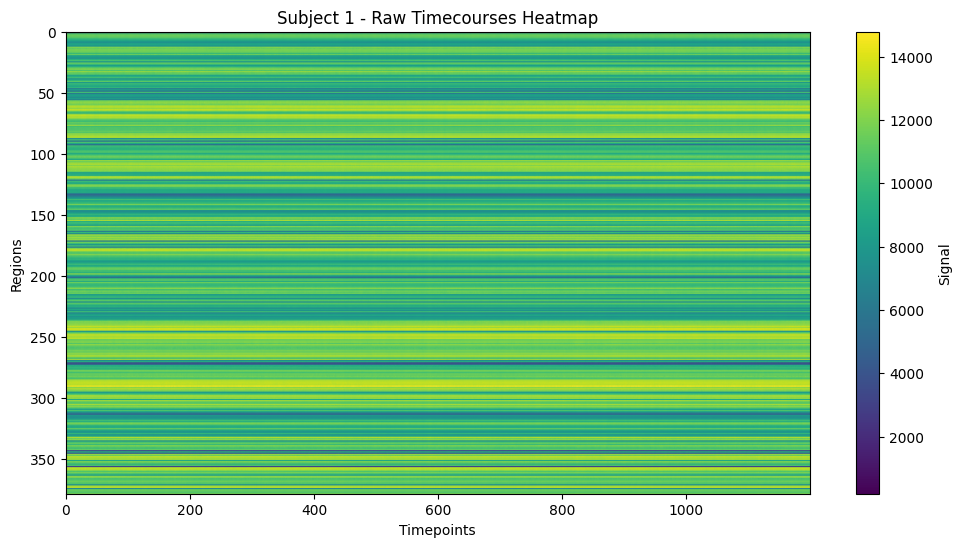

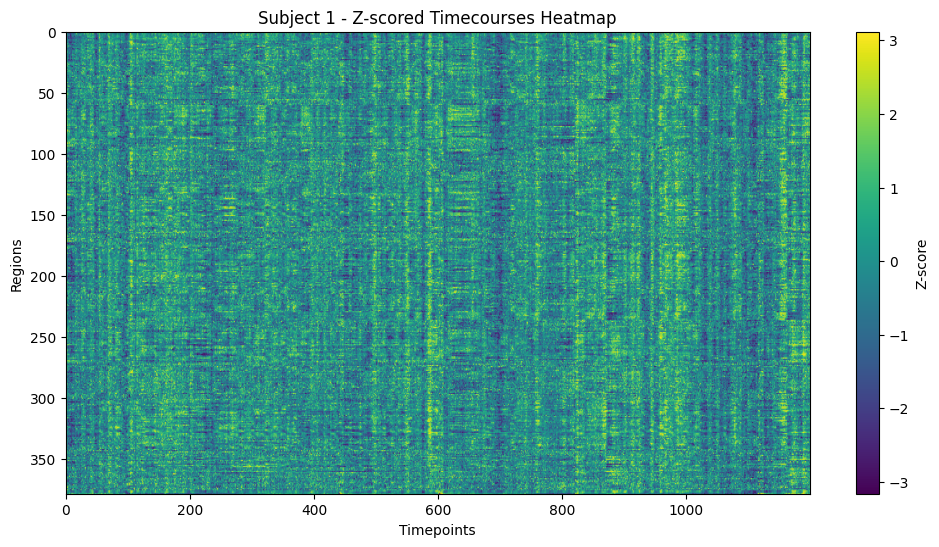

In [3]:
# ===================== TIMECOURSE HEATMAP =====================
subject_idx = 0  # choose a subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Raw timecourses heatmap
plt.figure(figsize=(12,6))
plt.imshow(tc_sub, aspect='auto', cmap='viridis')
plt.colorbar(label='Signal')
plt.xlabel('Timepoints')
plt.ylabel('Regions')
plt.title(f'Subject {subject_idx+1} - Raw Timecourses Heatmap')
plt.show()

# Z-scored timecourses heatmap
plt.figure(figsize=(12,6))
plt.imshow(tc_sub_z, aspect='auto', cmap='viridis')
plt.colorbar(label='Z-score')
plt.xlabel('Timepoints')
plt.ylabel('Regions')
plt.title(f'Subject {subject_idx+1} - Z-scored Timecourses Heatmap')
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


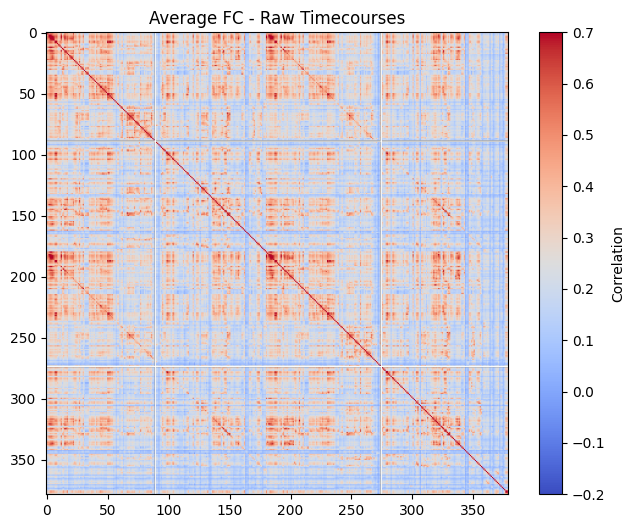

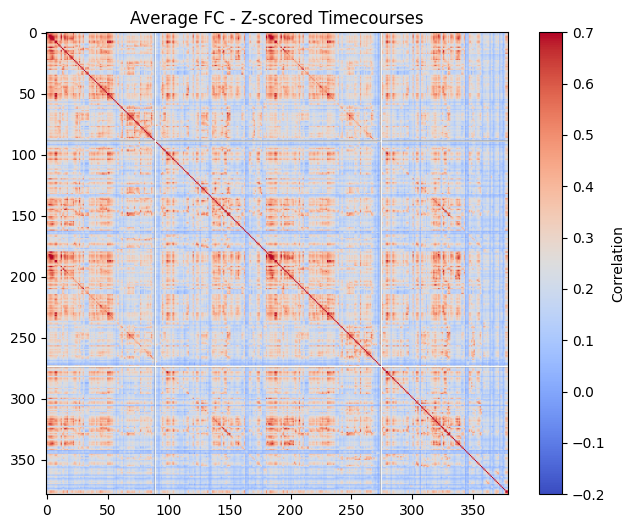

In [18]:

# ===================== FUNCTIONAL CONNECTIVITY =====================
subject_idx = 0  # example subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Compute correlation matrices
FC_raw = np.corrcoef(tc_sub)
FC_z = np.corrcoef(tc_sub_z)

# Average across subjects
FC_all = np.zeros((tc_sub.shape[0], tc_sub.shape[0]))
FC_all_z = np.zeros_like(FC_all)
n_subjects = TCSvar.shape[2]
for s in range(n_subjects):
    FC_all += np.corrcoef(TCSvar[:, :, s])
    FC_all_z += np.corrcoef(zscore(TCSvar[:, :, s], axis=1, ddof=1))
FC_all /= n_subjects
FC_all_z /= n_subjects

# ===================== PLOT AVERAGE FC =====================
plt.figure(figsize=(8,6))
plt.imshow(FC_all, cmap='coolwarm', vmin=-0.2, vmax=0.7)
plt.colorbar(label='Correlation')
plt.title('Average FC - Raw Timecourses')
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(FC_all_z, cmap='coolwarm', vmin=-0.2, vmax=0.7)
plt.colorbar(label='Correlation')
plt.title('Average FC - Z-scored Timecourses')
plt.show()



In [17]:
print(yeo_labels_var.shape)


(379,)


In [16]:
# ===================== REORDER REGIONS BY NETWORK =====================
# Load vector mapping regions to Yeo networks:

yeo_labels_file = os.path.join(path_exercise, 'DATA', 'yeo_labels.mat')
yeo_labels = scipy.io.loadmat(yeo_labels_file)


yeo_labels_var = yeo_labels['yeo_labels']
yeo_labels_var = np.squeeze(yeo_labels_var)
yeo_labels_var = yeo_labels_var.flatten()
print(yeo_labels_var.shape)

# Then you can reorder:
order = np.argsort(yeo_labels_var)
FC_all_sorted = FC_all[order][:, order]
plt.imshow(FC_all_sorted, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title("Average FC - Regions sorted by Yeo network")
plt.colorbar(label='Pearson r')
plt.show()

# ===================== ADDITIONAL IDEAS =====================
# - Compute FC z-score per subject before averaging
# - Compare intra-network vs inter-network connectivity
# - Plot FC distributions for selected networks
# - Save FC matrices as .npy or .mat for further analysis

(379,)


NameError: name 'FC_mean' is not defined

In [33]:
yeo_labels_var.shape


(379, 1)

In [ ]:
# ===================== UNMOUNT & REMOUNT DRIVE (useful if you add new files) =====================

from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===================== CHECK FILES SEEN BY COLAB =====================
import os

path = '/content/drive/MyDrive/ColabNotebooks2026/EE-629/EX_1/DATA/fMRI_vols'
print(os.listdir(path))


['Cov_s5frfMRI_REST1_LR0011.nii', 'Cov_s5frfMRI_REST1_LR0012.nii', 'Cov_s5frfMRI_REST1_LR0013.nii', 'Cov_s5frfMRI_REST1_LR0014.nii', 'Cov_s5frfMRI_REST1_LR0015.nii', 'Cov_s5frfMRI_REST1_LR0016.nii', 'Cov_s5frfMRI_REST1_LR0017.nii', 'Cov_s5frfMRI_REST1_LR0018.nii', 'Cov_s5frfMRI_REST1_LR0019.nii', 'Cov_s5frfMRI_REST1_LR0020.nii', 'Cov_s5frfMRI_REST1_LR0021.nii', 'Cov_s5frfMRI_REST1_LR0022.nii', 'Cov_s5frfMRI_REST1_LR0023.nii', 'Cov_s5frfMRI_REST1_LR0024.nii', 'Cov_s5frfMRI_REST1_LR0025.nii', 'Cov_s5frfMRI_REST1_LR0026.nii', 'Cov_s5frfMRI_REST1_LR0027.nii', 'Cov_s5frfMRI_REST1_LR0028.nii', 'Cov_s5frfMRI_REST1_LR0029.nii', 'Cov_s5frfMRI_REST1_LR0030.nii', 'Cov_s5frfMRI_REST1_LR0031.nii', 'Cov_s5frfMRI_REST1_LR0032.nii', 'Cov_s5frfMRI_REST1_LR0033.nii', 'Cov_s5frfMRI_REST1_LR0034.nii', 'Cov_s5frfMRI_REST1_LR0035.nii', 'Cov_s5frfMRI_REST1_LR0036.nii', 'Cov_s5frfMRI_REST1_LR0037.nii', 'Cov_s5frfMRI_REST1_LR0038.nii', 'Cov_s5frfMRI_REST1_LR0039.nii', 'Cov_s5frfMRI_REST1_LR0040.nii', 'Cov_s5fr